<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2d6a9f 100%); padding: 40px 32px 32px 32px; border-radius: 12px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; margin: 0 0 6px 0; font-family: 'Segoe UI', sans-serif; font-weight: 700;">
    Capstone Project -- Pressure Forecasting
  </h1>
  <h2 style="color: #a8d4f5; font-size: 1.2em; margin: 0 0 18px 0; font-family: 'Segoe UI', sans-serif; font-weight: 400;">
    Kadi Tereka Sadaraka Lubang &middot; Track C &middot; How well can we forecast next month's reservoir pressure using production and injection data?
  </h2>
  <hr style="border: 1px solid rgba(255,255,255,0.25); margin: 16px 0;">
  <table style="color: #cce4ff; font-family: 'Segoe UI', sans-serif; font-size: 0.95em;">
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Week:</strong></td><td>15-16 of 16 -- Capstone Project</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Module:</strong></td><td>Capstone: Designing and Delivering Your Own ML Project</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Prerequisites:</strong></td><td>Capstone Parts 1 and 2</td>
    </tr>
    <tr>
      <td style="padding: 3px 24px 3px 0;"><strong>Course:</strong></td><td>Machine Learning for Petroleum Engineers &amp; Geoscientists</td>
    </tr>
  </table>
</div>

---
## Table of Contents

1. [Project Charter](#1-project-charter)
2. [Setup](#2-setup)
3. [Data and EDA](#3-data-and-eda)
4. [Evaluation Design](#4-evaluation-design)
5. [Baselines](#5-baselines) -- *Milestone 1 ends here*
6. [Improved Models](#6-improved-models)
7. [Results Table](#7-results-table)
8. [Error Analysis](#8-error-analysis)
9. [Uncertainty](#9-uncertainty)
10. [Conclusions, Limitations, Next Steps](#10-conclusions-limitations-next-steps)
11. [Model Card](#11-model-card)

---
## 1. Project Charter

| Item | My answer |
|---|---|
| **Question** |How well can we forecast next month's reservoir pressure using production and injection data?|
| **Who would use the answer, and for what decision?** |Reservoir/production engineers monitoring field pressure decline, to decide whether ML-based forecasts are reliable enough to support decisions like injection scheduling or production planning, versus just extrapolating the last known value.|
| **Target variable (units)** |Reservoir pressure (Pressure_psia), in psia.|
| **Input features, and why each is physically sensible** | Pressure, oil production rate and water injection rate. Producing oil depletes the reservoir pressure while water injection repressurizes the reservoir. Pressure predicts itself through its own autocorrelation and decline over time.|
| **Features I will NOT use, and why** |Gas Production Rate because the gas is an associated gas rather than an independent driver;Gas Injection Rate because Volve was primarily a water-injection supported field.|
| **Evaluation split, and why it matches real use** |Temporal train/test( chronological time) split — train on the first 94 months, test on the most recent 18 months. This mirrors real deployment: forecasts are always made forward from known history, never using future data.|
| **Primary metric (units)** |RMSE and MAE, in psia. |
| **Baseline(s)** |Naive baseline - Persistence model ;Classical Machine Learning baselines - Random Forest (two variants: pressure-lags-only and pressure+drivers).|
| **Success criterion** |LSTM RMSE/MAE lower than the persistence baseline (85.3 psia RMSE / 49.5 psia MAE)|
| **Biggest risk** |The dataset is small (112 months). The LSTM may have enough data to learn without overfitting.|

---
## 2. Setup

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = "../data"

COLORS = {"blue": "#2d6a9f", "orange": "#e07b39", "green": "#2ca87f",
          "purple": "#8456b8", "navy": "#1a3a5c", "grey": "#b9c6d1"}

LOG_PATH = "../results/capstone_results_log.csv"
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

def log_result(track, model, split, metrics, notes=""):
    """Append one experiment (including failures) to the results log."""
    row = {"timestamp": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), "track": track, "model": model,
           "split": split, **{k: round(float(v), 4) for k, v in metrics.items()}, "notes": notes}
    log = pd.read_csv(LOG_PATH) if os.path.exists(LOG_PATH) else pd.DataFrame()
    log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
    log.to_csv(LOG_PATH, index=False)
    return log

---
## 3. Data and EDA

**Data source:** `data/volve_field_production.csv` is a monthly field-level summary — average 
reservoir pressure, cumulative oil/gas/water production, and injection volumes — sourced from a 
public, community-processed version of the dataset (`yohanesnuwara/pyreservoir` on GitHub), 
itself built from Volve's Eclipse reservoir simulation history-match output.

**Size:** *112 months, from `2007-09-01` to `2016-12-01`, with 8 columns*

**Cleaning steps:**
- *Parsed `Date` to datetime, set as index and sorted chronologically*
- *Created Monthly Oil Rate and Monthly Water Injection Rate columns, converting units from STB to MMSTB*

**Figures:**

1. *Figure — Pressure, Oil Production Rate and Water Injection Rate over time;*
   *Takeaway: Pressure responds to oil production and water injection*
2. *Figure — Pressure, Gas Production Rate and Gas Injection Rate over time;*
   *Takeaway: Pressure responds to gas production. No gas injection in this field*
3. *Figure — Oil Production Rate, Gas Production Rate and Gas/Oil Ratio over time;*
   *Takeaway: Gas in this field is an associated gas, not an independent driver*

In [2]:
# Load and clean your data here
volve = pd.read_csv(f"{DATA_DIR}/volve_field_production.csv", parse_dates=["Date"])
volve = volve.sort_values("Date").reset_index(drop=True) 


print(f"Records: {volve.shape[0]} months, {volve['Date'].min().date()} to {volve['Date'].max().date()}")
volve.head()

Records: 112 months, 2007-09-01 to 2016-12-01


,Date,Pressure_psia,CumOil_STB,CumGas_SCF,CumWater_STB,GasInj_SCF,WaterInj_STB,GOR_scf_per_stb
0,2007-09-01,4780.59,0,0,0.0,0,0,0.0
1,2007-10-01,4780.59,0,0,0.0,0,0,0.0
2,2007-11-01,4780.59,0,0,0.0,0,0,0.0
3,2007-12-01,4780.59,0,0,0.0,0,0,0.0
4,2008-01-01,4780.59,0,0,0.0,0,0,0.0


In [3]:
# Find month to month change using .diff()
# Cumulative volumes -> monthly rates (millions of STB per month keeps numbers readable)
volve["OilRate_MMSTB"] = volve["CumOil_STB"].diff().fillna(0.0) / 1e6
volve["WaterInjRate_MMSTB"] = volve["WaterInj_STB"].diff().fillna(0.0) / 1e6

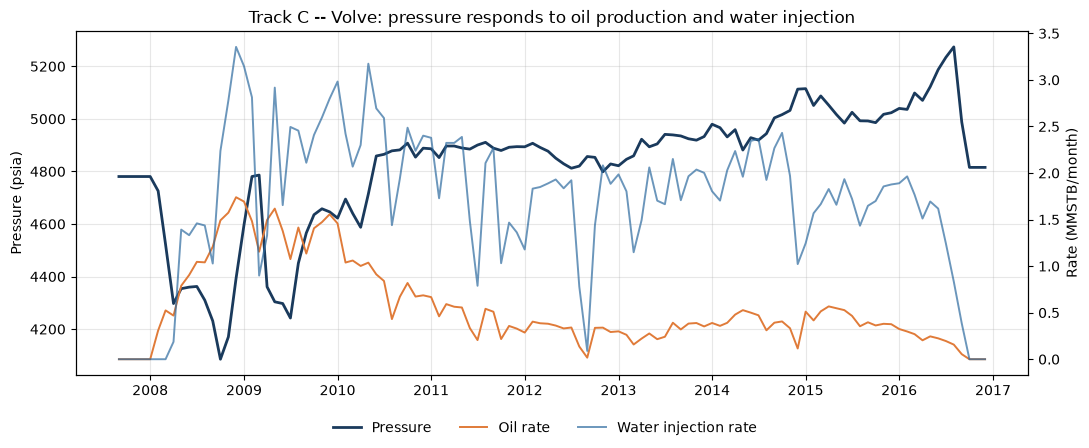

Pressure drops with oil production, and recovers under water injection.


In [4]:
# EDA figure 1
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(volve["Date"], volve["Pressure_psia"], color=COLORS["navy"], lw=2, label="Pressure")
ax1.set_ylabel("Pressure (psia)"); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(volve["Date"], volve["OilRate_MMSTB"], color=COLORS["orange"], lw=1.4, label="Oil rate")
ax2.plot(volve["Date"], volve["WaterInjRate_MMSTB"], color=COLORS["blue"], lw=1.4, alpha=0.7, label="Water injection rate")
ax2.set_ylabel("Rate (MMSTB/month)")
fig.legend(loc="lower center", ncol=3, frameon=False)
ax1.set_title("Track C -- Volve: pressure responds to oil production and water injection")

plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

print("Pressure drops with oil production, and recovers under water injection.")

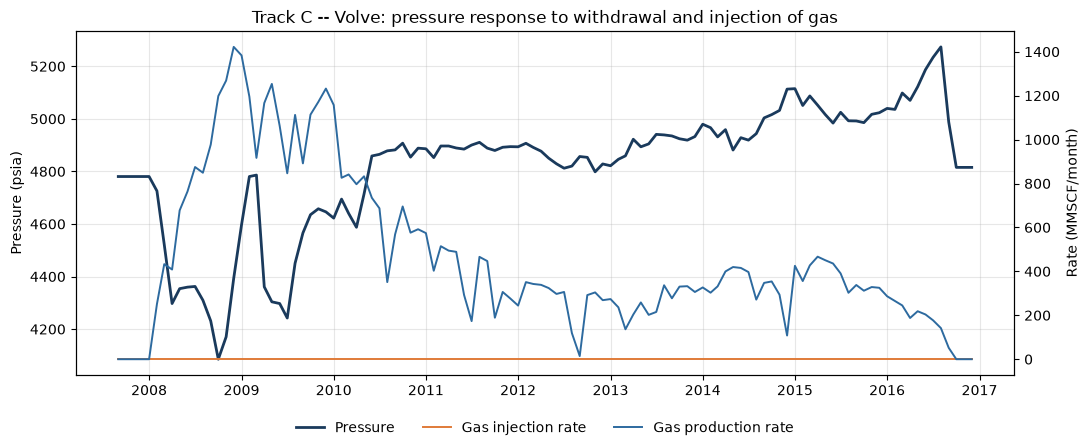

Pressure drops with gas production. There is no gas injection in this field


In [5]:
# Gas Production and Injection Rate
volve["GasProdRate_MMSCF"] = volve["CumGas_SCF"].diff().fillna(0.0) / 1e6
volve["GasInjRate_MMSCF"] = volve["GasInj_SCF"].diff().fillna(0.0) / 1e6

# EDA figure 2
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(volve["Date"], volve["Pressure_psia"], color=COLORS["navy"], lw=2, label="Pressure")
ax1.set_ylabel("Pressure (psia)"); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(volve["Date"], volve["GasInjRate_MMSCF"], color=COLORS["orange"], lw=1.4, label="Gas injection rate")
ax2.plot(volve["Date"], volve["GasProdRate_MMSCF"], color=COLORS["blue"], lw=1.4, label="Gas production rate")
ax2.set_ylabel("Rate (MMSCF/month)")
fig.legend(loc="lower center", ncol=3, frameon=False)
ax1.set_title("Track C -- Volve: pressure response to withdrawal and injection of gas")

plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

print("Pressure drops with gas production. There is no gas injection in this field")

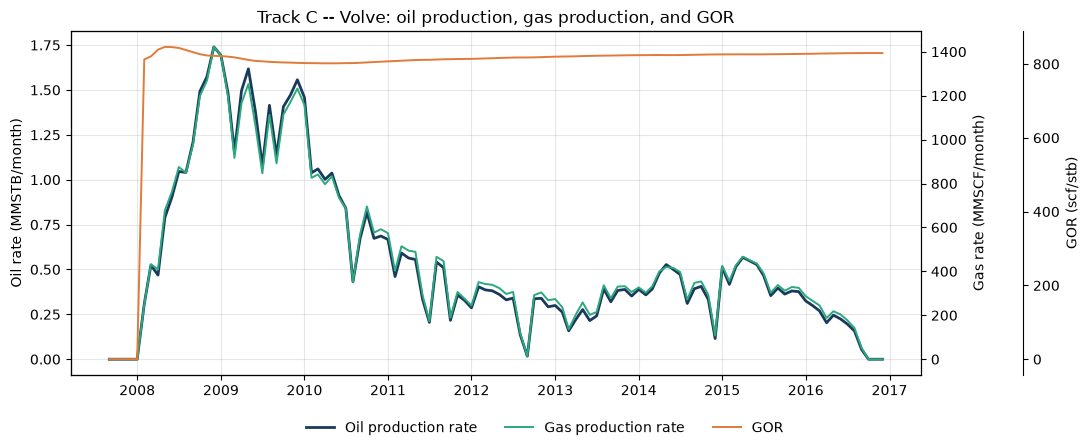

Gas production closely tracks oil production, confirming it is associated gas. GOR remains relatively stable.


In [6]:
# EDA figure 3
fig, ax1 = plt.subplots(figsize=(11, 4.5))

ax1.plot(volve["Date"], volve["OilRate_MMSTB"], color=COLORS["navy"], lw=2, label="Oil production rate")
ax1.set_ylabel("Oil rate (MMSTB/month)")
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(volve["Date"], volve["GasProdRate_MMSCF"], color=COLORS["green"], lw=1.4, label="Gas production rate")
ax2.set_ylabel("Gas rate (MMSCF/month)")
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))
ax3.plot(volve["Date"], volve["GOR_scf_per_stb"], color=COLORS["orange"], lw=1.4, label="GOR")
ax3.set_ylabel("GOR (scf/stb)")

fig.legend(loc="lower center", ncol=3, frameon=False)
ax1.set_title("Track C -- Volve: oil production, gas production, and GOR")
plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show()

print("Gas production closely tracks oil production, confirming it is associated gas. GOR remains relatively stable.")

---
## 4. Evaluation Design

**Split strategy:** Reservoir pressure prediction is a time series problem, so the appropriate 
split is a temporal train/test (chronological time) split — training on the first portion of the data and testing on 
the most recent, held-out portion. This prevents the model from seeing the future during 
training, matching how the model would actually be used in production (forecasting forward 
from known history, never from future data).

**Metrics:** MAE and RMSE, both in units of psia (reservoir pressure).

**Leakage checks:**
- The scaler is fit on training data only, then applied to test data via `transform()` — never 
  refit or exposed to test values.
- The window lookback is included only so the first test sample has enough history; it does not 
  allow training data to overlap with test targets.
- No shuffling of time-ordered data before splitting.

In [7]:
# Implement the split here (Time split)
LAGS = 6             # Prediction window
TEST_MONTHS = 18     # Held-out months

# Drivers of pressure
DRIVERS = ["Pressure_psia", "OilRate_MMSTB", "WaterInjRate_MMSTB"]

# Lagged features for regression
lagged = pd.concat({f"{c}_lag{k}": volve[c].shift(k) for c in DRIVERS for k in range(1, LAGS + 1)}, axis=1)
tab = pd.concat([volve[["Date", "Pressure_psia"]], lagged], axis=1).dropna().reset_index(drop=True)

train_C, test_C = tab.iloc[:-TEST_MONTHS], tab.iloc[-TEST_MONTHS:]
all_lags = list(lagged.columns)
p_lags = [c for c in all_lags if c.startswith("Pressure")]
print(f"Train months: {len(train_C)}  ({train_C.Date.min().date()} to {train_C.Date.max().date()})")
print(f"Test months:  {len(test_C)}  ({test_C.Date.min().date()} to {test_C.Date.max().date()})")


Train months: 88  (2008-03-01 to 2015-06-01)
Test months:  18  (2015-07-01 to 2016-12-01)


---
## 5. Baselines

*Naive persistence Baseline and Random Forest Baselines*

In [8]:
# Baseline 1 (naive)
preds_C = {"Persistence": test_C["Pressure_psia_lag1"].values}

In [9]:
# Baseline 2 (classical ML)
for name, cols in [("RF -- pressure lags only", p_lags), ("RF -- pressure + drivers", all_lags)]:
    rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=42)
    preds_C[name] = rf.fit(train_C[cols], train_C["Pressure_psia"]).predict(test_C[cols])

In [10]:
# Evaluation
def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

scores_C = pd.DataFrame({"RMSE (psia)": {k: rmse(test_C["Pressure_psia"], v) for k, v in preds_C.items()},
                         "MAE (psia)": {k: mean_absolute_error(test_C["Pressure_psia"], v) for k, v in preds_C.items()}}).round(1)

scores_C


,RMSE (psia),MAE (psia)
Persistence,85.3,49.5
RF -- pressure lags only,92.8,68.1
RF -- pressure + drivers,95.1,68.4


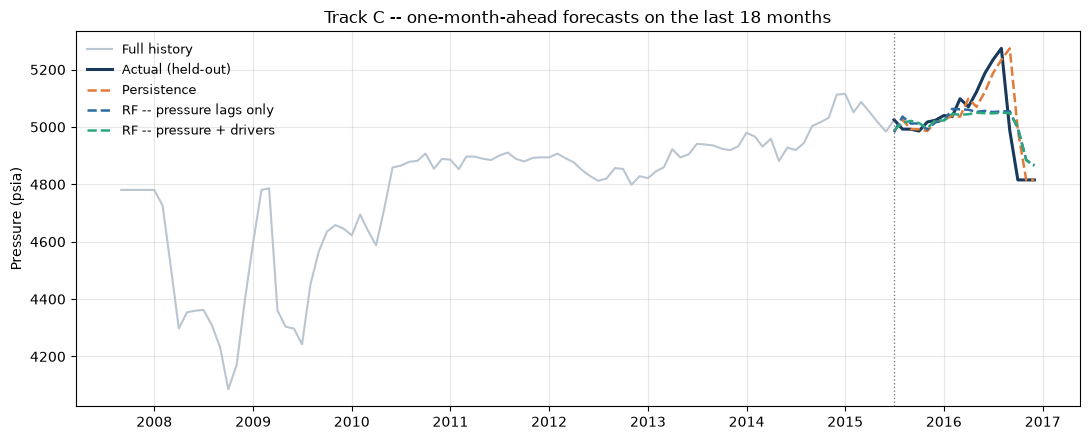

In [11]:
plt.figure(figsize=(11, 4.5))
plt.plot(volve["Date"], volve["Pressure_psia"], color=COLORS["grey"], lw=1.5, label="Full history")
plt.plot(test_C["Date"], test_C["Pressure_psia"], color=COLORS["navy"], lw=2.2, label="Actual (held-out)")
styles = {"Persistence": COLORS["orange"], "RF -- pressure lags only": COLORS["blue"], "RF -- pressure + drivers": COLORS["green"]}
for name, col in styles.items():
    plt.plot(test_C["Date"], preds_C[name], color=col, lw=1.8, ls="--", label=name)
plt.axvline(test_C["Date"].iloc[0], color="gray", ls=":", lw=1)
plt.ylabel("Pressure (psia)"); plt.grid(alpha=0.3); plt.legend(frameon=False, fontsize=9)
plt.title("Track C -- one-month-ahead forecasts on the last 18 months")
plt.tight_layout(); plt.show()

In [12]:
# Logging results
log_result(track="C", 
           model="Persistence", 
           split="Temporal train/test", 
           metrics={"RMSE_psia": rmse(test_C["Pressure_psia"], preds_C["Persistence"]), 
                    "MAE_psia": mean_absolute_error(test_C["Pressure_psia"], preds_C["Persistence"])},
           notes="Best baseline model - The model to beat")

log_result(track="C", 
           model="Random Forest -- Pressure lags only", 
           split="Temporal train/test", 
           metrics={"RMSE_psia": rmse(test_C["Pressure_psia"], preds_C["RF -- pressure lags only"]), 
                    "MAE_psia": mean_absolute_error(test_C["Pressure_psia"], preds_C["RF -- pressure lags only"])}, 
           notes="RF does not perform better than persistence, does not extrapolate well on unseen data")

log_result(track="C", 
           model="Random Forest -- Pressure + Drivers", 
           split="Temporal train/test", 
           metrics={"RMSE_psia": rmse(test_C["Pressure_psia"], preds_C["RF -- pressure + drivers"]), 
             "MAE_psia": mean_absolute_error(test_C["Pressure_psia"], preds_C["RF -- pressure + drivers"])}, 
           notes="Additional drivers hurt the RF slightly")

,timestamp,track,model,split,RMSE_psia,MAE_psia,notes
0,2026-09-23 00:29,C,Persistence,Temporal train/test,85.3063,49.4778,Best baseline model - The model to beat
1,2026-09-23 00:29,C,Random Forest -- Pressure lags only,Temporal train/test,92.8296,68.1475,"RF does not perform better than persistence, d..."
2,2026-09-23 00:29,C,Random Forest -- Pressure + Drivers,Temporal train/test,95.1415,68.4280,Additional drivers hurt the RF slightly


**Milestone 1 summary.** The score to beat is the persistence baseline: RMSE = 85.3 psia, 
MAE = 49.5 psia. It outperforms both Random Forest variants — pressure-lags-only scores 
92.8 psia RMSE / 68.1 psia MAE, and pressure-plus-drivers scores 95.1 psia RMSE / 68.4 psia MAE, 
with the added driver features actually hurting performance slightly rather than helping. My 
next step is to try an LSTM to see if a sequence model can capture temporal patterns well enough 
to beat the persistence baseline, where the classical ML approaches so far have not.

---
## 6. Improved Models

*[For each experiment: the hypothesis in one sentence, the single change, the result. Tune
hyperparameters on training data only.]*

**Hypothesis 1:** *[The model fails on X because Y.]*

In [13]:
# Experiment 1
# Three Feature LSTM on level pressure 

#  LSTM Split
WINDOW = 6
TEST_MONTHS = 18

# Three-feature array
series = volve[DRIVERS].values.astype("float32")

# Temporal train/test split
n_test = TEST_MONTHS
n_train = len(series) - n_test

train_raw = series[:n_train]
test_raw = series[n_train - WINDOW:]

# Feature scaler and Target Scaler separately
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0,1))

# Fit feature scaler on train only
train_scaled = feature_scaler.fit_transform(train_raw)
test_scaled = feature_scaler.transform(test_raw) 

target_scaled = target_scaler.fit(train_raw[:, [0]])

train_dates = volve["Date"].iloc[:n_train]
test_dates = volve["Date"].iloc[n_train:]

print(f"Training months: {n_train} (from {train_dates.min().date()} to {test_dates.max().date()})")
print(f"Held-out test months: {n_test} (from {test_dates.min().date()} to {test_dates.max().date()})")

Training months: 94 (from 2007-09-01 to 2016-12-01)
Held-out test months: 18 (from 2015-07-01 to 2016-12-01)


In [14]:
# Pressure LSTM definition
class PressureLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)   
        last_step = out[:, -1, :]
        return self.head(last_step)

In [15]:
# Making windows
def make_windows(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window, :])
        y.append(data[i + window, 0])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

In [16]:
X_train, y_train = make_windows(train_scaled, WINDOW)
X_test, y_test = make_windows(test_scaled, WINDOW)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).unsqueeze(-1)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test).unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=8, shuffle=True)

In [17]:
# Building model
lstm_model1 = PressureLSTM(input_size=3, hidden_size=16, num_layers=1)

lstm_params = sum(p.numel() for p in lstm_model1.parameters())

print(lstm_model1, "\n")
print(f"LSTM trainable parameters: {lstm_params}")

PressureLSTM(
  (lstm): LSTM(3, 16, batch_first=True)
  (head): Linear(in_features=16, out_features=1, bias=True)
) 

LSTM trainable parameters: 1361


In [18]:
# Training
def train_model(model, loader, n_epochs=200, lr=0.01, label="model"):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(loader.dataset)
        losses.append(epoch_loss)
        if (epoch + 1) % 40 == 0:
            print(f"[{label:4s}] epoch {epoch+1:3d}/{n_epochs} | train MSE (scaled) = {epoch_loss:.5f}")
    return losses

In [19]:
def evaluate(model, X_train_t, y_train_t, X_test_t, y_test_t, scaler):
    model.eval()
    with torch.no_grad():
        train_pred_scaled = model(X_train_t).numpy()
        test_pred_scaled = model(X_test_t).numpy()
    train_pred = scaler.inverse_transform(train_pred_scaled)
    test_pred = scaler.inverse_transform(test_pred_scaled)
    train_true = scaler.inverse_transform(y_train_t.numpy())
    test_true = scaler.inverse_transform(y_test_t.numpy())
    rmse = mean_squared_error(test_true, test_pred) ** 0.5
    mae = mean_absolute_error(test_true, test_pred)
    return dict(train_pred=train_pred, test_pred=test_pred, train_true=train_true,
                test_true=test_true, rmse=rmse, mae=mae)

In [20]:
# Training models
print("\nTraining LSTM...")
lstm_losses1 = train_model(model=lstm_model1, loader=train_loader, n_epochs=200, lr=0.01, label="LSTM")

# Evaluation
lstm_eval1 = evaluate(model=lstm_model1, X_train_t=X_train_t, y_train_t=y_train_t, X_test_t=X_test_t, y_test_t=y_test_t, scaler=target_scaler)

print(f"\n{'Model':<30}{'Test RMSE (psia)':<30}{'Test MAE (psia)':<30}")
print("-" * 90)
print(f"{'LSTM Level Pressure':<30}{lstm_eval1['rmse']:<30.1f}{lstm_eval1['mae']:<30.1f}")


Training LSTM...
[LSTM] epoch  40/200 | train MSE (scaled) = 0.00309
[LSTM] epoch  80/200 | train MSE (scaled) = 0.00152
[LSTM] epoch 120/200 | train MSE (scaled) = 0.00117
[LSTM] epoch 160/200 | train MSE (scaled) = 0.00107
[LSTM] epoch 200/200 | train MSE (scaled) = 0.00092

Model                         Test RMSE (psia)              Test MAE (psia)               
------------------------------------------------------------------------------------------
LSTM Level Pressure           87.5                          67.2                          


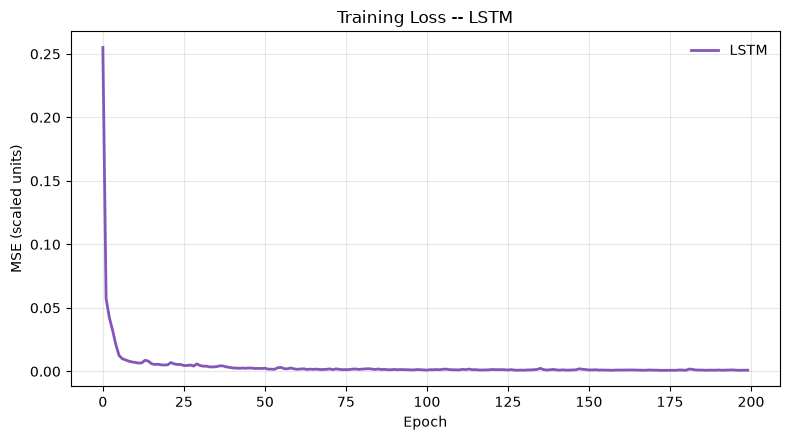

In [21]:
plt.figure(figsize=(8, 4.5))
plt.plot(lstm_losses1, color="#8456b8", linewidth=2, label="LSTM")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled units)"); plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.title("Training Loss -- LSTM")
plt.tight_layout()
plt.show()

In [22]:
log_result(track="C", 
           model="LSTM -- 3 features (pressure + drivers)",
           split="Temporal train/test",
           metrics={"RMSE_psia": lstm_eval1["rmse"],"MAE_psia": lstm_eval1["mae"]},
           notes="Roughly matches persistence on RMSE, worse on MAE"
)

,timestamp,track,model,split,RMSE_psia,MAE_psia,notes
0,2026-09-23 00:29,C,Persistence,Temporal train/test,85.3063,49.4778,Best baseline model - The model to beat
1,2026-09-23 00:29,C,Random Forest -- Pressure lags only,Temporal train/test,92.8296,68.1475,"RF does not perform better than persistence, d..."
2,2026-09-23 00:29,C,Random Forest -- Pressure + Drivers,Temporal train/test,95.1415,68.4280,Additional drivers hurt the RF slightly
3,2026-09-23 00:29,C,LSTM -- 3 features (pressure + drivers),Temporal train/test,87.4658,67.2193,"Roughly matches persistence on RMSE, worse on MAE"


**Hypothesis 2:** *[The model fails on X because Y.]*

In [23]:
# Experiment 2
# LSTM on pressure difference 

def make_windows_delta(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window, :])
        y.append(data[i + window, 0] - data[i + window - 1, 0])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

In [24]:
X_train_2, y_train_2 = make_windows_delta(train_scaled, WINDOW)
X_test_2, y_test_2 = make_windows_delta(test_scaled, WINDOW)

X_train_t_2 = torch.tensor(X_train_2)
y_train_t_2 = torch.tensor(y_train_2).unsqueeze(-1)
X_test_t_2 = torch.tensor(X_test_2)
y_test_t_2 = torch.tensor(y_test_2).unsqueeze(-1)

train_loader_2 = DataLoader(TensorDataset(X_train_t_2, y_train_t_2), batch_size=8, shuffle=True)

In [25]:
# Building model
lstm_model2 = PressureLSTM(input_size=3, hidden_size=16, num_layers=1)

lstm_params = sum(p.numel() for p in lstm_model2.parameters())

print(lstm_model2, "\n")
print(f"LSTM trainable parameters: {lstm_params}")

PressureLSTM(
  (lstm): LSTM(3, 16, batch_first=True)
  (head): Linear(in_features=16, out_features=1, bias=True)
) 

LSTM trainable parameters: 1361


In [26]:
def evaluate_delta(model, X_train_t, X_test_t, target_scaler, raw_train, raw_test, window):
    model.eval()
    with torch.no_grad():
        train_pred_scaled = model(X_train_t).numpy().flatten()
        test_pred_scaled = model(X_test_t).numpy().flatten()

    scale = target_scaler.scale_[0]
    train_delta_pred = train_pred_scaled / scale
    test_delta_pred = test_pred_scaled / scale

    n_train_samples = len(train_delta_pred)
    n_test_samples = len(test_delta_pred)

    train_prev = raw_train[window - 1: window - 1 + n_train_samples, 0]
    train_true = raw_train[window: window + n_train_samples, 0]
    train_pred = train_prev + train_delta_pred

    test_prev = raw_test[window - 1: window - 1 + n_test_samples, 0]
    test_true = raw_test[window: window + n_test_samples, 0]
    test_pred = test_prev + test_delta_pred

    rmse = mean_squared_error(test_true, test_pred) ** 0.5
    mae = mean_absolute_error(test_true, test_pred)
    return dict(train_pred=train_pred, test_pred=test_pred,
                train_true=train_true, test_true=test_true, rmse=rmse, mae=mae)

In [27]:

# Training models
print("\nTraining LSTM...")
lstm_losses2 = train_model(model=lstm_model2, loader=train_loader_2, n_epochs=200, lr=0.01, label="LSTM")

# Evaluation
lstm_eval2 = evaluate_delta(model=lstm_model2, X_train_t=X_train_t_2,  X_test_t=X_test_t_2, target_scaler=target_scaler, raw_train=train_raw, raw_test=test_raw, window=WINDOW)

print(f"\n{'Model':<30}{'Test RMSE (psia)':<30}{'Test MAE (psia)':<30}")
print("-" * 90)
print(f"{'LSTM Delta Pressure':<30}{lstm_eval2['rmse']:<30.1f}{lstm_eval2['mae']:<30.1f}")


Training LSTM...
[LSTM] epoch  40/200 | train MSE (scaled) = 0.00108
[LSTM] epoch  80/200 | train MSE (scaled) = 0.00069
[LSTM] epoch 120/200 | train MSE (scaled) = 0.00054
[LSTM] epoch 160/200 | train MSE (scaled) = 0.00040
[LSTM] epoch 200/200 | train MSE (scaled) = 0.00043

Model                         Test RMSE (psia)              Test MAE (psia)               
------------------------------------------------------------------------------------------
LSTM Delta Pressure           79.4                          51.2                          


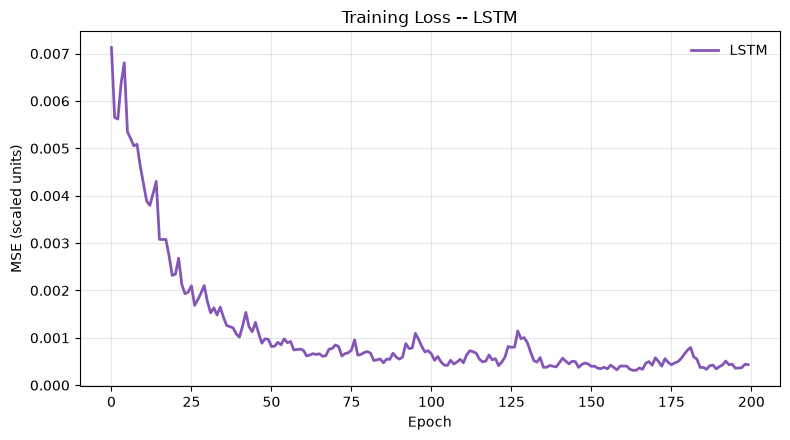

In [28]:
plt.figure(figsize=(8, 4.5))
plt.plot(lstm_losses2, color="#8456b8", linewidth=2, label="LSTM")
plt.xlabel("Epoch"); plt.ylabel("MSE (scaled units)"); plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.title("Training Loss -- LSTM")
plt.tight_layout()
plt.show()

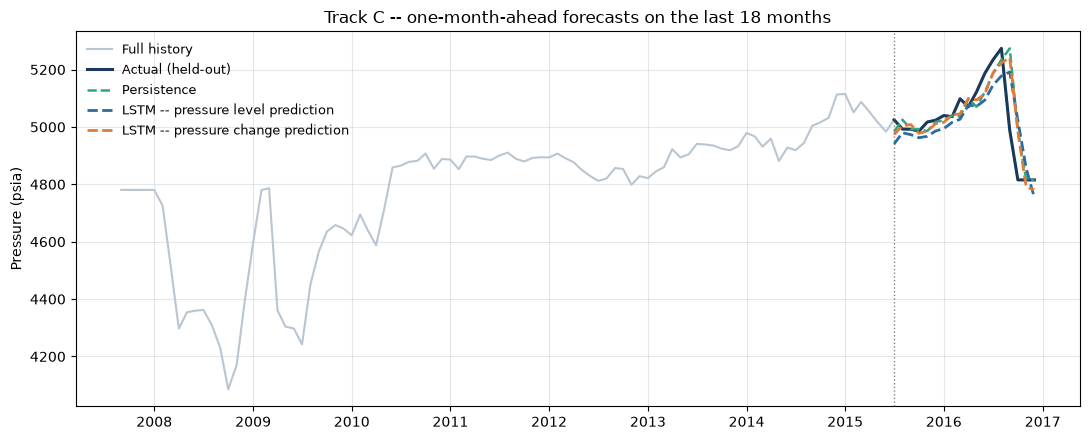

In [29]:
plt.figure(figsize=(11, 4.5))
plt.plot(volve["Date"], volve["Pressure_psia"], color=COLORS["grey"], lw=1.5, label="Full history")
plt.plot(test_C["Date"], test_C["Pressure_psia"], color=COLORS["navy"], lw=2.2, label="Actual (held-out)")
plt.plot(test_C["Date"], preds_C["Persistence"], color=COLORS["green"], lw=1.8, ls="--", label="Persistence")
plt.plot(test_dates, lstm_eval1["test_pred"], color=COLORS["blue"], linewidth=2, linestyle="--", label="LSTM -- pressure level prediction")
plt.plot(test_dates, lstm_eval2["test_pred"], color=COLORS["orange"], linewidth=2, linestyle="--", label="LSTM -- pressure change prediction")
plt.axvline(test_C["Date"].iloc[0], color="gray", ls=":", lw=1)
plt.ylabel("Pressure (psia)"); plt.grid(alpha=0.3); plt.legend(frameon=False, fontsize=9)
plt.title("Track C -- one-month-ahead forecasts on the last 18 months")
plt.tight_layout(); plt.show()

In [30]:
log_result(track="C", 
           model="LSTM -- 3 features (pressure + drivers)",
           split="Temporal train/test",
           metrics={"RMSE_psia": lstm_eval2["rmse"],"MAE_psia": lstm_eval2["mae"]},
           notes="Beats persistence on RMSE, comparable on MAE"
)

,timestamp,track,model,split,RMSE_psia,MAE_psia,notes
0,2026-09-23 00:29,C,Persistence,Temporal train/test,85.3063,49.4778,Best baseline model - The model to beat
1,2026-09-23 00:29,C,Random Forest -- Pressure lags only,Temporal train/test,92.8296,68.1475,"RF does not perform better than persistence, d..."
2,2026-09-23 00:29,C,Random Forest -- Pressure + Drivers,Temporal train/test,95.1415,68.4280,Additional drivers hurt the RF slightly
3,2026-09-23 00:29,C,LSTM -- 3 features (pressure + drivers),Temporal train/test,87.4658,67.2193,"Roughly matches persistence on RMSE, worse on MAE"
4,2026-09-23 00:29,C,LSTM -- 3 features (pressure + drivers),Temporal train/test,79.3961,51.2499,"Beats persistence on RMSE, comparable on MAE"


---
## 7. Results Table

*[One table: every baseline and model on the same split, same metrics. This table goes straight into the
report and onto slide 6.]*

In [31]:
pd.read_csv(LOG_PATH) if os.path.exists(LOG_PATH) else "No experiments logged yet."

,timestamp,track,model,split,RMSE_psia,MAE_psia,notes
0,2026-09-23 00:29,C,Persistence,Temporal train/test,85.3063,49.4778,Best baseline model - The model to beat
1,2026-09-23 00:29,C,Random Forest -- Pressure lags only,Temporal train/test,92.8296,68.1475,"RF does not perform better than persistence, d..."
2,2026-09-23 00:29,C,Random Forest -- Pressure + Drivers,Temporal train/test,95.1415,68.4280,Additional drivers hurt the RF slightly
3,2026-09-23 00:29,C,LSTM -- 3 features (pressure + drivers),Temporal train/test,87.4658,67.2193,"Roughly matches persistence on RMSE, worse on MAE"
4,2026-09-23 00:29,C,LSTM -- 3 features (pressure + drivers),Temporal train/test,79.3961,51.2499,"Beats persistence on RMSE, comparable on MAE"


---
## 8. Error Analysis

*[Break the error down by a meaningful group (well, formation, throw, noise, month). Show examples of
failures. Explain where and why the model fails.]*

In [32]:
# Error breakdown

---
## 9. Uncertainty

*[Your method (empirical interval, confidence triage, ...) and its check on held-out data.]*

In [33]:
# Uncertainty and its check

---
## 10. Conclusions, Limitations, Next Steps

*[The answer to your charter question in 2-3 sentences, with a number and units. Then limitations and
next steps -- honest and specific.]*

---
## 11. Model Card

| Field | Your answer |
|---|---|
| **Model name and version** | |
| **Intended use** | |
| **Not intended for** | |
| **Training data** | |
| **Inputs and units** | |
| **Output and units** | |
| **Evaluation split** | |
| **Headline performance** | |
| **Where it fails** | |
| **Uncertainty** | |
| **Known limitations and risks** | |
| **How to reproduce** | |

In [34]:
# Library versions for requirements.txt
import platform, sklearn, matplotlib
print(f"# Python {platform.python_version()}")
for lib in [np, pd, matplotlib, sklearn, torch]:
    print(f"{lib.__name__}=={lib.__version__.split('+')[0]}")

# Python 3.11.15
numpy==2.4.6
pandas==3.0.3
matplotlib==3.11.0
sklearn==1.9.0
torch==2.11.0
